In [21]:
from __future__ import annotations

import sys, os
sys.path.append(os.path.abspath(".."))

# Данные

In [2]:
from torch_geometric.data import Dataset, Data
import torch
import numpy as np
import pandas as pd
from scipy import stats

/home/mitsuri/Code/Python/gnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


вспомогательные функции для построения матрицы смежности

In [3]:
def pearson_matrix(df: pd.DataFrame) -> np.ndarray:
  """Корреляция Пирсона между всеми парами признаков."""
  return df.corr(method='pearson').values

def spearman_matrix(df: pd.DataFrame) -> np.ndarray:
  """Ранговая корреляция Спирмена (устойчива к выбросам)."""
  return df.corr(method='spearman').values

def mutual_info_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Нормированная взаимная информация (NMI) через оценку плотности.
  Симметрична, лежит в [0, 1].
  """
  n_features = df.shape[1]
  mi = np.zeros((n_features, n_features))
  arr = df.values.astype(np.float32)
  for i in range(n_features):
    for j in range(i + 1, n_features):
      # kernel-density оценка двумерной MI через корреляцию Спирмена
      # (быстрое приближение без sklearn)
      r, _ = stats.spearmanr(arr[:, i], arr[:, j])
      r = np.clip(r, -1 + 1e-9, 1 - 1e-9)
      nmi = abs(r) # приближение: |r| ≈ NMI для монотонных связей
      mi[i, j] = nmi
      mi[j, i] = nmi

  np.fill_diagonal(mi, 1.0)
  return mi

def partial_corr_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Частичная корреляция через обращение корреляционной матрицы.
  Показывает прямую связь между парой переменных при фиксации остальных.
  """
  corr = df.corr(method='pearson').values
  try:
    inv = np.linalg.pinv(corr)
    d = np.sqrt(np.diag(inv))
    partial = -inv / np.outer(d, d)
    np.fill_diagonal(partial, 1.0)
    return np.abs(partial)
  except np.linalg.LinAlgError:
    return np.abs(corr)

EDGE_STRATEGIES = {
  'pearson':      pearson_matrix,
  'spearman':     spearman_matrix,
  'mutual_info':  mutual_info_matrix,
  'partial_corr': partial_corr_matrix,
}

In [55]:
class PolyFilmDataset(Dataset):
  def __init__(
    self,
    df: pd.DataFrame,
    target_col: str = 'target',
    edge_strategy: str | list[str] = 'pearson',
    threshold: float = 0.3,
    self_loops: bool = True,
    normalize_features: bool = True,
  ):
    super().__init__()

    self._feature_cols: list[str] = [c for c in df.columns if c != target_col]
    self._n_nodes: int = len(self._feature_cols)

    feature_df = df[self._feature_cols].copy().astype(np.float32)
    labels = df[target_col].values.astype(np.int64)

    if normalize_features:
      self._mean = feature_df.mean()
      self._std = feature_df.std().replace(0, 1)
      feature_df = (feature_df - self._mean) / self._std
    else:
      self._mean = None
      self._std = None

    self._features: np.ndarray = feature_df.values
    self._labels: np.ndarray = labels

    strategies = [edge_strategy] if isinstance(edge_strategy, str) else edge_strategy
    for s in strategies:
      if s not in EDGE_STRATEGIES:
        raise ValueError(
          f"Неизвестная стратегия '{s}'. "
          f"Доступные: {list(EGDE_STRATEGIES)}"
        )

    weight_matrices = [
      np.abs(EDGE_STRATEGIES[s](feature_df))
      for s in strategies
    ]

    combined: np.ndarray = np.mean(weight_matrices, axis=0)
    np.fill_diagonal(combined, 0.0)

    src, dst = np.where(combined >= threshold)
    edge_weights = combined[src, dst].astype(np.float32)

    if self_loops:
      loop_idx = np.arange(self._n_nodes)
      src = np.concatenate([src, loop_idx])
      dst = np.concatenate([dst, loop_idx])
      edge_weights = np.concatenate([edge_weights, np.ones(self._n_nodes)])

    self._edge_index: torch.Tensor = torch.tensor(
      np.stack([src, dst], axis=0), dtype=torch.long
    )
    self._edge_attr: torch.Tensor = torch.tensor(
      edge_weights,  dtype=torch.float32
    ).unsqueeze(1)

  def len(self) -> int:
    return len(self._labels)

  def get(self, idx: int) -> Data:
    """
    Возвращает граф для одного наблюдения.
 
    Граф:
    x          — (N_nodes, 1)  значения признаков для данного наблюдения
    edge_index — (2, E)        индексы рёбер (общие для всех графов)
    edge_attr  — (E, 1)        веса рёбер (общие для всех графов)
    y          — (1,)          бинарная метка
    """
    
    # Значения признаков текущего наблюдения — каждый узел получает своё число
    node_features = torch.tensor(
      self._features[idx], dtype=torch.float32
    ).unsqueeze(1)

    label = torch.tensor(self._labels[idx], dtype=torch.long)

    return Data(
      x             = node_features,
      edge_index    = self._edge_index,
      edge_attr     = self._edge_attr,
      y             = label,
      num_nodes     = self._n_nodes,
    )

  @property
  def num_node_features(self) -> int:
    return 1

  @property
  def num_classes(self) -> int:
    return 2

  @property
  def feature_names(self) -> list[str]:
    return self._feature_cols

  @property
  def num_edges(self) -> int:
    return self._edge_index.shape[1]

  def __repr__(self) -> str:
    return (
      f"{self.__class__.__name__}("
      f"samples={self.len()}, "
      f"nodes={self._n_nodes}, "
      f"edges={self.num_edges})"
    )

# Модель

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.nn import (
  GATv2Conv,
  global_add_pool,
  global_mean_pool,
  global_max_pool,
)
from torch_geometric.data import Batch
from torch_focalloss import BinaryFocalLoss

In [6]:
class FocalLoss(nn.Module):
  """
  Focal Loss для бинарной классификации.
  Подавляет лёгкие примеры и фокусируется на трудных.
 
  Parameters
  ----------
  alpha : float
      Вес положительного класса (дефект). alpha > 0.5 усиливает штраф
      за пропущенные дефекты (recall ↑).
  gamma : float
      Параметр фокусировки. gamma=0 → обычный BCE. gamma=2 стандартно.
  """
  def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
    super().__init__()
    self.alpha = alpha
    self.gamma = gamma

  def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
    probs = F.softmax(logits, dim=-1)
    probs_true = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

    alpha_t = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
    focal_weight = alpha_t * (1.0 - probs_true) ** self.gamma

    ce = F.cross_entropy(logits, targets, reduction='none')
    loss = focal_weight * ce
    return loss.mean()


In [7]:
class GATBlock(nn.Module):
  """
  Один слой графового внимания с нормализацией и остаточным соединением.
 
  Parameters
  ----------
  in_channels : int
  out_channels : int      размерность выхода на голову (head)
  heads : int             число голов внимания
  dropout : float         вероятность dropout на веса внимания и активации
  edge_dim : int | None   размерность edge_attr; None — не используется
  residual : bool         добавлять ли skip-connection
  """
  def __init__(
    self,
    in_channels: int,
    out_channels: int,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    residual: bool = True,
  ):
    super().__init__()

    self.conv = GATv2Conv(
      in_channels   = in_channels,
      out_channels  = out_channels,
      heads         = heads,
      dropout       = dropout,
      edge_dim      = edge_dim,
      concat        = True,
      add_self_loops= False,
    )

    out_total = out_channels * heads
    self.norm = nn.BatchNorm1d(out_total)
    self.dropout = nn.Dropout(p=dropout)

    self.residual = residual
    if residual and in_channels != out_total:
      self.skip = nn.Linear(in_channels, out_total, bias=False)
    else:
      self.skip = None

  def forward(
    self,
    x: Tensor,
    edge_index: Tensor,
    edge_attr: Tensor | None = None,
  ) -> Tensor:
    out = self.conv(x, edge_index, edge_attr=edge_attr)
    out = self.norm(out)
    out = F.elu(out)
    out = self.dropout(out)

    if self.residual:
      res = self.skip(x) if self.skip is not None else x
      out = out + res

    return out

In [8]:
class PolymerGAT(nn.Module):
  """
  Графовая сеть внимания для бинарной классификации дефектов плёнки.
 
  Схема прохождения данных:
      x  →  InputProjection  →  GATBlock × n_layers
         →  GlobalPooling (mean + max + add)
         →  BatchNorm  →  Linear  →  Dropout  →  Linear(2)
 
  Parameters
  ----------
  in_channels : int
      Размерность признака узла из датасета (обычно 1).
  hidden_channels : int
      Число скрытых каналов на голову в каждом GAT-слое.
  n_layers : int
      Число GATBlock-слоёв (рекомендуется 2–4).
  heads : int
      Число голов внимания.
  dropout : float
      Dropout в GAT-блоках и классификационной голове.
  edge_dim : int | None
      Размерность edge_attr. Передать None, чтобы игнорировать веса рёбер.
  pooling : str
      Стратегия глобального пулинга: "mean", "max", "add", "concat".
      "concat" объединяет mean + max + add → более богатое представление.
  """
  def __init__(
    self,
    in_channels: int = 1,
    hidden_channels: int = 32,
    n_layers: int = 3,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    pooling: str = 'concat',
  ):
    super().__init__()

    if n_layers < 1:
      raise ValueError('n_layers должно быть >= 1')

    self.pooling = pooling

    self.input_proj = nn.Sequential(
      nn.Linear(in_channels, hidden_channels),
      nn.BatchNorm1d(hidden_channels),
      nn.ELU(),
    )

    self.gat_blocks = nn.ModuleList()
    in_ch = hidden_channels
    for i in range(n_layers):
      is_last = (i == n_layers - 1)
      block = GATBlock(
        in_channels=in_ch,
        out_channels=hidden_channels,
        heads=heads,
        dropout=dropout,
        edge_dim=edge_dim,
        residual=True,
      )
      self.gat_blocks.append(block)
      in_ch = hidden_channels * heads

    graph_embed_dim = in_ch * 3 if pooling == 'concat' else in_ch

    self.classifier = nn.Sequential(
      nn.BatchNorm1d(graph_embed_dim),
      nn.Linear(graph_embed_dim, hidden_channels*2),
      nn.ELU(),
      nn.Dropout(p=dropout),
      nn.Linear(hidden_channels*2, 2),
    )

  def forward(self, data: Data | Batch) -> Tensor:
    """
    Parameters
    ----------
    data : torch_geometric.data.Data | Batch
        Граф или батч графов из DataLoader.
 
    Returns
    -------
    Tensor  shape (B, 2) — логиты классов
    """
    x, edge_index, edge_attr, batch = (
      data.x,
      data.edge_index,
      data.edge_attr,
      data.batch,
    )

    x = self.input_proj(x)

    for block in self.gat_blocks:
      x = block(x, edge_index, edge_attr)

    if self.pooling == 'concat':
      graph_emb = torch.cat([
        global_mean_pool(x, batch),
        global_max_pool(x, batch),
        global_add_pool(x, batch),
      ], dim=-1)
    elif self.pooling == 'mean':
      graph_emb = global_mean_pool(x, batch)
    elif self.pooling == 'max':
      graph_emb = global_max_pool(x, batch)
    elif self.pooling == 'add':
      graph_emb = global_add_pool(x, batch)
    else:
      raise ValueError(f'Неизвестый pooling: {self.pooling!r}')

    logits = self.classifier(graph_emb)

    return logits

  @torch.no_grad()
  def predict_proba(self, data: Data | Batch) -> Tensor:
    """Возвращает вероятности классов (B, 2)."""
    self.eval()
    return F.softmax(self(data), dim=-1)

  @torch.no_grad()
  def predict(self, data: Data | Batch) -> Tensor:
    """Возвращает предсказанный класс (B,)."""
    return self.predict_proba(data).argmax(dim=-1)

  def count_parameters(self) -> int:
    return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [9]:
def build_model(
  in_channels: int = 1,
  hidden_channels: int = 32,
  n_layers: int = 3,
  heads: int = 4,
  dropout: float = 0.3,
  edge_dim: int | None = 1,
  pooling: str = 'concat',
) -> PolymerGAT:
  """Создаёт и возвращает инициализированную модель."""
  model = PolymerGAT(
    in_channels     =in_channels,
    hidden_channels =hidden_channels,
    n_layers        =n_layers,
    heads           =heads,
    dropout         =dropout,
    edge_dim        =edge_dim,
    pooling         = pooling,
  )

  return model

In [13]:
from typing import NamedTuple

class SplitResult(NamedTuple):
  train: pd.DataFrame
  val: pd.DataFrame
  test: pd.DataFrame

In [14]:
def stratified_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  train_size: float = 0.70,
  val_size: float = 0.15,
  test_size: float = 0.15,
  random_state: int = 42,
  verbose: bool = True,
) -> SplitResult:
  """
  Делит DataFrame на train / val / test с сохранением доли классов.
 
  Parameters
  ----------
  df : pd.DataFrame
      Исходный датафрейм со всеми признаками и целевой переменной.
  target_col : str
      Название столбца с бинарной меткой (0 / 1).
  train_size, val_size, test_size : float
      Доли разбиения. Должны в сумме давать 1.0.
  random_state : int
      Зерно генератора для воспроизводимости.
  verbose : bool
      Печатать ли статистику по сплитам.
 
  Returns
  -------
  SplitResult(train, val, test) — три DataFrame с reset_index.
  """
  if not np.isclose(train_size + val_size + test_size, 1.0):
    raise ValueError(
      f'Сумма долей должна быть 1.0'
      f'получено {train_size + val_size + test_size:.4f}'
    )

  if target_col not in df.columns:
    raise KeyError(f"Стобец '{target_col}' не найден в DataFrame")

  unique_classes = df[target_col].unique()
  if not set(unique_classes).issubset({0.0, 1.0}):
    raise ValueError(f"Ожидаются только значения 0 и 1 в '{target_col}'")

  rng = np.random.default_rng(random_state)

  idx_pos = df.index[df[target_col] == 1].to_numpy().copy()
  idx_neg = df.index[df[target_col] == 0].to_numpy().copy()

  rng.shuffle(idx_pos)
  rng.shuffle(idx_neg)

  def _split_indices(idx: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Режет массив индексов на три части по заданным пропорциям."""
    n = len(idx)
    n_train = int(np.floor(n * train_size))
    n_val = int(np.floor(n * val_size))
    return idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]

  train_pos, val_pos, test_pos = _split_indices(idx_pos)
  train_neg, val_neg, test_neg = _split_indices(idx_neg)

  def _make_split(pos: np.ndarray, neg: np.ndarray) -> pd.DataFrame:
    combined = np.concatenate([pos, neg])
    rng.shuffle(combined)
    return df.loc[combined].reset_index(drop=True)

  train_df = _make_split(train_pos, train_neg)
  val_df = _make_split(val_pos, val_neg)
  test_df = _make_split(test_pos, test_neg)

  if verbose:
    _print_split_stats(df, train_df, val_df, test_df, target_col)

  return SplitResult(train=train_df, val=val_df, test=test_df)

def _print_split_stats(
  original: pd.DataFrame,
  train: pd.DataFrame,
  val: pd.DataFrame,
  test: pd.DataFrame,
  target_col: str,
):
  total = len(original)

  header = f"{'Сплит':<10} {'Строк':>7} {'% от всех':>10} {'Дефекты':>9} {'% дефектов':>12}"
  sep = '─' * len(header)

  print(sep)
  print(header)
  print(sep)

  for name, df in [('Исходный', original), ('Train', train), ('Val', val), ('Test', test)]:
    n = len(df)
    pct = 100 * n / total
    n_pos = (df[target_col] == 1).sum()
    pct_pos = 100 * n_pos / n if n > 0 else 0.0
    print(f"{name:<10} {n:>7,}  {pct:>9.1f}%  {n_pos:>8,}  {pct_pos:>10.1f}%")

    print(sep)

# Цикл обучения

In [16]:
import csv
import time
from pathlib import Path
from dataclasses import dataclass, field, asdict
from torch_geometric.loader import DataLoader

@dataclass
class EpochMetrics:
  epoch:     int
  phase:     str          # "train" | "val" | "test"
  loss:      float
 
  # Регрессионные метрики (на вероятностях / мягких предсказаниях)
  mae:       float = 0.0
  rmse:      float = 0.0
  wape:      float = 0.0
 
  # Классификационные метрики (на жёстких предсказаниях)
  precision: float = 0.0
  recall:    float = 0.0
  f1:        float = 0.0
  accuracy:  float = 0.0
 
  duration_sec: float = 0.0
 
  def __str__(self) -> str:
    return (
        f"[{self.phase.upper():>5}] epoch={self.epoch:>3d} | "
        f"loss={self.loss:.4f}  "
        f"mae={self.mae:.4f}  rmse={self.rmse:.4f}  wape={self.wape:.4f}  "
        f"prec={self.precision:.4f}  rec={self.recall:.4f}  "
        f"f1={self.f1:.4f}  acc={self.accuracy:.4f}  "
        f"({self.duration_sec:.1f}s)"
    )

def compute_metrics(
  epoch: int,
  phase: str,
  loss: float,
  y_true: np.ndarray,      # (N,)  int  0/1
  y_prob: np.ndarray,      # (N,)  float  P(class=1)
  y_pred: np.ndarray,      # (N,)  int  0/1
  duration_sec: float,
) -> EpochMetrics:
  """
  Считает все метрики по собранным за эпоху предсказаниям.
 
  Регрессионные метрики применяются к вероятностям y_prob vs y_true,
  что позволяет оценить качество калибровки модели.
  """
 
  # ── Регрессионные метрики (вероятность vs бинарная метка) ────────────────
  errors   = y_prob - y_true                          # (N,)
  mae      = float(np.mean(np.abs(errors)))
  rmse     = float(np.sqrt(np.mean(errors ** 2)))
 
  # WAPE: взвешенная абсолютная процентная ошибка
  # знаменатель — сумма истинных меток; если все 0 → wape=0 (деление защищено)
  denom = np.sum(np.abs(y_true))
  wape  = float(np.sum(np.abs(errors)) / denom) if denom > 0 else 0.0
 
  # ── Классификационные метрики (жёсткие предсказания) ────────────────────
  tp = int(np.sum((y_pred == 1) & (y_true == 1)))
  fp = int(np.sum((y_pred == 1) & (y_true == 0)))
  fn = int(np.sum((y_pred == 0) & (y_true == 1)))
  tn = int(np.sum((y_pred == 0) & (y_true == 0)))
 
  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  f1        = (
      2 * precision * recall / (precision + recall)
      if (precision + recall) > 0 else 0.0
  )
  accuracy  = (tp + tn) / len(y_true) if len(y_true) > 0 else 0.0
 
  return EpochMetrics(
    epoch        = epoch,
    phase        = phase,
    loss         = loss,
    mae          = mae,
    rmse         = rmse,
    wape         = wape,
    precision    = float(precision),
    recall       = float(recall),
    f1           = float(f1),
    accuracy     = float(accuracy),
    duration_sec = duration_sec,
  )

In [84]:
class MetricsLogger:
  def __init__(self, log_path: str | Path | None = None):
    self.log_path = Path(log_path) if log_path else None
    if self.log_path is not None:
      with self.log_path.open('w') as f:
        pass

    self._csv_initialized = False
    self.history: list[EpochMetrics] = []

  def log(self, metrics: EpochMetrics):
    self.history.append(metrics)
    print(metrics)

    if self.log_path is not None:
      row = asdict(metrics)
      write_header = not self._csv_initialized and not self.log_path.exists()
      with self.log_path.open('a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
          writer.writeheader()
        writer.writerow(row)
      self._csv_initialized = True

  def best(self, phase: str = 'val', key: str = 'loss', mode: str = 'min') -> EpochMetrics:
    subset = [m for m in self.history if m.phase == phase]
    if not subset:
      raise ValueError(f"Нет записей для фазы '{phase}'")
    return min(subset, key=lambda m: getattr(m, key)) if mode == 'min' \
    else max(subset, key=lambda m: getattr(m, key))

In [33]:
def _run_epoch(
  model: PolymerGAT,
  loader: DataLoader,
  criterion: nn.Module,
  device: torch.device,
  optimizer: torch.optim.Optimizer | None = None,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
  """
  Выполняет один проход по DataLoader.
 
  Returns
  -------
  avg_loss, y_true, y_prob, y_pred
  """
  is_train = optimizer is not None
  model.train(is_train)
  ctx = torch.enable_grad() if is_train else torch.no_grad()

  total_loss = 0.0
  all_true, all_prob, all_pred = [], [], []

  with ctx:
    for batch in loader:
      batch = batch.to(device)

      logits = model(batch)

      loss = criterion(logits, batch.y)

      if is_train:
        optimizer.zero_grad()
        loss.backward()
        # gradient clipping — стабилизирует обучение на графах
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

      probs = torch.softmax(logits, dim=-1)[:, 1] # P(дефект)
      preds = logits.argmax(dim=-1)

      total_loss += loss.item() * batch.num_graphs
      all_true.append(batch.y.cpu().numpy())
      all_prob.append(probs.detach().cpu().numpy())
      all_pred.append(preds.detach().cpu().numpy())

  n = sum(len(t) for t in all_true)
  avg_loss = total_loss / n if n > 0 else 0.0
  return (
    avg_loss,
    np.concatenate(all_true),
    np.concatenate(all_prob),
    np.concatenate(all_pred),
  )

In [19]:
class EarlyStopping:
  """
  Останавливает обучение, если val-метрика не улучшается `patience` эпох.
 
  Parameters
  ----------
  patience : int
    Сколько эпох ждать улучшения.
  min_delta : float
    Минимальное изменение, считающееся улучшением.
  mode : str
    "min" для loss/ошибок, "max" для accuracy/f1/recall.
  checkpoint_path : str | Path
    Куда сохранять лучшие веса модели.
  """
  def __init__(
    self,
    patience: int = 10,
    min_delta: float = 1e-4,
    mode: str = 'min',
    checkpoint_path: str | Path = 'best_model.pt',
  ):
    self.patience = patience
    self.min_delta = min_delta
    self.mode = mode
    self.checkpoint_path = checkpoint_path
    self._best_score: float | None = None
    self._counter = 0
    self.triggered = False

  def step(self, score: float, model: PolymerGAT) -> bool:
    """
    Проверяет улучшение и сохраняет веса при необходимости.
 
    Returns
    -------
    True, если обучение следует продолжать; False — остановить.
    """
    improved = self._is_improved(score)

    if improved:
      self._best_score = score
      self._counter = 0
      torch.save(model.state_dict(), self.checkpoint_path)
    else:
      self._counter += 1
      if self._counter >= self.patience:
        self.triggered = True
        return False

    return True

  def _is_improved(self, score: float) -> bool:
    if self._best_score is None:
      return True
    if self.mode == 'min':
      return score < self._best_score - self.min_delta

    return score > self._best_score + self.min_delta

  @property
  def best_score(self) -> float | None:
    return self._best_score

  @property
  def epochs_without_improvement(self) -> int:
    return self._counter

In [20]:
@dataclass
class TrainConfig:
  # main params
  n_epochs: int = 100
  learning_rate: float = 1e-3
  weight_decay: float = 1e-4

  # early stopping params
  es_patience: int = 15
  es_min_delta: float = 1e-4
  es_monitor: str = 'loss'  # метрика val для early stopping
  es_mode: str = 'min'  # 'min' | 'max'

  # LR scheduler
  lr_factor: float = 0.5
  lr_patience: int = 7
  lr_min: float = 1e-6

  # focal loss
  focal_alpha: float = 0.75
  focal_gamma: float = 2.0

  # paths
  checkpoint_path: str = 'best_model.pt'
  log_csv_path: str = 'training_log.csv'

  # device
  device: str = 'auto' # 'auto' | 'cpu' | 'cuda' | 'mps'

In [35]:
def train(
  model: PolymerGAT,
  train_loader: DataLoader,
  val_loader: DataLoader,
  test_loader: DataLoader | None = None,
  config: TrainConfig | None = None,
) -> MetricsLogger:
  """
  Полный цикл обучения: train → val (каждую эпоху) → test (в конце).
 
  Parameters
  ----------
  model         : инициализированная PolymerGAT
  train_loader  : DataLoader обучающего датасета
  val_loader    : DataLoader валидационного датасета
  test_loader   : DataLoader тестового датасета (опционально)
  config        : TrainConfig с гиперпараметрами
 
  Returns
  -------
  MetricsLogger со всей историей метрик
  """
  if config is None:
    config = TrainConfig()

  if config.device == 'auto':
    device = torch.device(
      'cuda' if torch.cuda.is_available()
      else 'mps' if torch.backends.mps.is_available()
      else 'cpu'
    )
  else:
    device = torch.device(config.device)

  model = model.to(device)
  print(f'Устройство: {device}')
  print(f"Параметров модели: {model.count_parameters():,}\n")

  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = config.learning_rate,
    weight_decay = config.weight_decay,
  )

  criterion = FocalLoss(alpha=config.focal_alpha, gamma=config.focal_gamma)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = config.es_mode,
    factor = config.lr_factor,
    patience = config.lr_patience,
    min_lr = config.lr_min,
  )

  early_stopping = EarlyStopping(
    patience = config.es_patience,
    min_delta = config.es_min_delta,
    mode = config.es_mode,
    checkpoint_path = config.checkpoint_path,
  )
  logger = MetricsLogger(log_path=config.log_csv_path)

  for epoch in range(1, config.n_epochs + 1):
    # Train
    t0 = time.perf_counter()
    tr_loss, tr_true, tr_prob, tr_pred = _run_epoch(
      model, train_loader, criterion, device, optimizer
    )
    train_metrics = compute_metrics(
      epoch, 'train', tr_loss,
      tr_true, tr_prob, tr_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(train_metrics)

    # Val
    t0 = time.perf_counter()
    val_loss, val_true, val_prob, val_pred = _run_epoch(
      model, val_loader, criterion, device, optimizer=None
    )
    val_metrics = compute_metrics(
      epoch, 'val', val_loss,
      val_true, val_prob, val_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(val_metrics)

    # Scheduler step
    monitor_value = getattr(val_metrics, config.es_monitor)
    scheduler.step(monitor_value)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"lr={current_lr:.2e}  "
          f"es_counter={early_stopping.epochs_without_improvement}/{config.es_patience}")

    # Early stopping
    should_continue = early_stopping.step(monitor_value, model)
    if not should_continue:
      print(f"\n⏹  Early stopping на эпохе {epoch}. "
            f"Лучший val {config.es_monitor}={early_stopping.best_score:.4f}")
      break

  best_ckpt = Path(config.checkpoint_path)
  if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print(f'Загружены лучшие веса из {best_ckpt}')

  if test_loader is not None:
    t0 = time.perf_counter()
    test_loss, test_true, test_prob, test_pred = _run_epoch(
      model, test_loader, criterion, device, optimizer=None
    )
    test_metrics = compute_metrics(
      epoch=0, phase='test',
      loss=test_loss,
      y_true=test_true, y_prob=test_prob, y_pred=test_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(test_metrics)
    print(f"\n{'='*70}")
    print('Итоговые метрики на тесте')
    print(f"{'='*70}")
    print(test_metrics)

  return logger

In [89]:
def main():
  import numpy as np
  import pandas as pd
  from torch_geometric.loader import DataLoader

  df = pd.read_excel('extcaland.xlsx')
  df.drop('timestamp', axis='columns', inplace=True)
  df['target'] = (df['target'] > 75).astype(int)

  splits = stratified_split(df, target_col = 'target')

  def make_dataset(split_df):
    return PolyFilmDataset(
      split_df,
      target_col = 'target',
      edge_strategy = ['pearson', 'spearman'],
      threshold = 0.5,
    )

  train_ds = make_dataset(splits.train)
  val_ds = make_dataset(splits.val)
  test_ds = make_dataset(splits.test)

  train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
  val_loader = DataLoader(val_ds, batch_size=64)
  test_loader = DataLoader(test_ds, batch_size=64)

  model = build_model(
    in_channels = train_ds.num_node_features,
    hidden_channels = 32,
    n_layers = 3,
    heads = 4,
    dropout = 0.3,
    edge_dim = 1,
    pooling = 'concat',
  )

  config = TrainConfig(
    n_epochs        = 100,
    learning_rate   = 1e-3,
    weight_decay    = 1e-4,
    es_patience     = 10,
    es_monitor      = "loss",
    es_mode         = "min",
    focal_alpha     = 0.95,
    focal_gamma     = 2.0,
    checkpoint_path = "best_model.pt",
    log_csv_path    = "training_log.csv",
  )

  logger = train(model, train_loader, val_loader, test_loader, config)

  best = logger.best(phase='val', key='loss', mode='min')
  print(f"\nЛучшая эпоха: {best.epoch}  val_loss={best.loss:.4f}  "
        f"val_recall={best.recall:.4f}  val_f1={best.f1:.4f}")

In [90]:
main()

────────────────────────────────────────────────────
Сплит        Строк  % от всех   Дефекты   % дефектов
────────────────────────────────────────────────────
Исходный    51,637      100.0%       233         0.5%
────────────────────────────────────────────────────
Train       36,145       70.0%       163         0.5%
────────────────────────────────────────────────────
Val          7,744       15.0%        34         0.4%
────────────────────────────────────────────────────
Test         7,748       15.0%        36         0.5%
────────────────────────────────────────────────────
Устройство: cpu
Параметров модели: 106,178

[TRAIN] epoch=  1 | loss=0.0041  mae=0.1901  rmse=0.2455  wape=42.1633  prec=0.0378  rec=0.3865  f1=0.0688  acc=0.9528  (145.9s)
[  VAL] epoch=  1 | loss=0.0030  mae=0.2199  rmse=0.2313  wape=50.0827  prec=0.4375  rec=0.2059  f1=0.2800  acc=0.9954  (17.8s)
lr=1.00e-03  es_counter=0/10
[TRAIN] epoch=  2 | loss=0.0032  mae=0.2019  rmse=0.2376  wape=44.7659  prec=0.0870

In [57]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

def visualize_graph(
  dataset: PolyFilmDataset,
  sample_idx: int = 0,
  edge_weight_threshold: float = 0.0,
  figsize: tuple = (14, 10),
  save_path: str | None = 'graph_sample.png',
):
  data = dataset.get(sample_idx)
  label = data.y.item()
  x = data.x.squeeze().numpy()
  ei = data.edge_index.numpy()
  ea = data.edge_attr.squeeze().numpy()
  names = dataset.feature_names

  G = nx.DiGraph()
  for i, name in enumerate(names):
    G.add_node(i, label=name, value=float(x[i]))

  for k in range(ei.shape[1]):
    src, dst = int(ei[0, k]), int(ei[1, k])
    w = float(ea[k])
    if src == dst:
      continue
    if w < edge_weight_threshold:
      continue
    G.add_edge(src, dst, weight=w)

  pos = nx.shell_layout(G)

  node_size = [800 + 1200 * min(abs(v), 2) / 2 for v in x]

  edge_list = list(G.edges())
  edge_weights = [G[u][v]['weight'] for u, v in edge_list]
  if edge_weights:
    norm = mcolors.Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
    cmap = cm.get_cmap('RdYlGn')
    edge_colors = [cmap(norm(w)) for w in edge_weights]
    edge_widths = [0.5 + 4.0 * norm(w) for w in edge_weights]
  else:
    edge_colors, edge_widths = [], []

  fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [3, 1]})
  ax_graph, ax_info = axes

  ax_graph.set_facecolor('#FAFAF8')
  nx.draw_networkx_nodes(
    G, pos, ax=ax_graph,
    linewidths=1.5,
    node_size=node_size
  )
  if edge_list:
    nx.draw_networkx_edges(
      G, pos, ax=ax_graph,
      edgelist=edge_list,
      edge_color=edge_colors,
      alpha=0.75,
      arrows=False,

      connectionstyle='arc3,rad=0.08'
    )

  for i, name in enumerate(names):
    has_self = any(
      int(ei[0, k]) == i and int(ei[1, k]) == i
      for k in range(ei.shape[1])
    )
    if has_self:
      px, py = pos[i]
      circle = plt.Circle((px, py + 0.13), 0.065,
                         fill=False, lw=1.2,
                         linestyle='dashed', alpha=0.5)
      ax_graph.add_patch(circle)

  labels_draw = {
    i: f"{names[i]}\n{x[i]:.2f}"
    for i in range(len(names))
  }
  nx.draw_networkx_labels(
    G, pos, labels=labels_draw,
    ax=ax_graph, font_size=7.5, font_family='sans-serif',
  )

  edge_labels = {
    (u, v): f"{G[u][v]['weight']:.2f}"
    for u, v in edge_list
    if G[u][v]['weight'] >= 0.5
  }
  nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    ax=ax_graph, font_size=6, alpha=0.7,
  )

  if edge_weights:
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_graph, shrink=0.6, pad=0.02)
    cbar.set_label('Вес ребра (корреляция)', fontsize=9)
    
  target_str = "Дефект (1)" if label == 1 else "Норма (0)"
  ax_graph.set_title(
    f"Граф наблюдения №{sample_idx} - Метка: {target_str}",
    fontsize=12, fontweight='bold', pad=14,
  )
  ax_graph.axis('off')

  ax_info.text(0.05, 0.52, 'Значения датчиков (норм.)',
              fontsize=9, fontweight='bold', va='top', transform=ax_info.transAxes)

  sorted_nodes = sorted(range(len(names)), key=lambda i: abs(x[i]), reverse=True)
  for row, i in enumerate(sorted_nodes[:10]):
    y = 0.46 - row * 0.042
    bar_len = min(abs(x[i]) / 3.0, 0.35)
    bar_color = '#E24B4A' if x[i] > 0 else '#378ADD'
    bar_rect = plt.Rectangle(
      (0.55, y-0.012), bar_len, 0.024,
      color=bar_color, alpha=0.6, transform=ax_info.transAxes,
    )
    ax_info.add_patch(bar_rect)
    ax_info.text(0.05, y, f"{names[i][:14]}", va="center",
                fontsize=7.5, transform=ax_info.transAxes)
    ax_info.text(0.53, y, f"{x[i]:+.3f}", va="center",
                fontsize=7.5, ha="right", transform=ax_info.transAxes)
 
    ax_info.text(0.05, 0.04,
                 f"Узлов: {len(names)}\nРёбер: {len(edge_list)}\n"
                 f"Порог: {edge_weight_threshold:.2f}",
                 fontsize=8, va="bottom", transform=ax_info.transAxes,
                 color="#666664")
 
    plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
 
    plt.show()

In [81]:
df = pd.read_excel('extcaland.xlsx')
df.drop('timestamp', axis='columns', inplace=True)
df['target'] = (df['target'] > 75).astype(int)
train_df, _, _ = stratified_split(df, target_col='target')
train_ds = PolyFilmDataset(
  train_df,
  target_col = 'target',
  edge_strategy = ['pearson', 'spearman'],
  threshold = 0.8,
  self_loops=False
)

────────────────────────────────────────────────────
Сплит        Строк  % от всех   Дефекты   % дефектов
────────────────────────────────────────────────────
Исходный    51,637      100.0%       233         0.5%
────────────────────────────────────────────────────
Train       36,145       70.0%       163         0.5%
────────────────────────────────────────────────────
Val          7,744       15.0%        34         0.4%
────────────────────────────────────────────────────
Test         7,748       15.0%        36         0.5%
────────────────────────────────────────────────────


/tmp/ipykernel_10041/667680928.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')
/tmp/ipykernel_10041/667680928.py:57: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


Сохранено: graph_sample.png


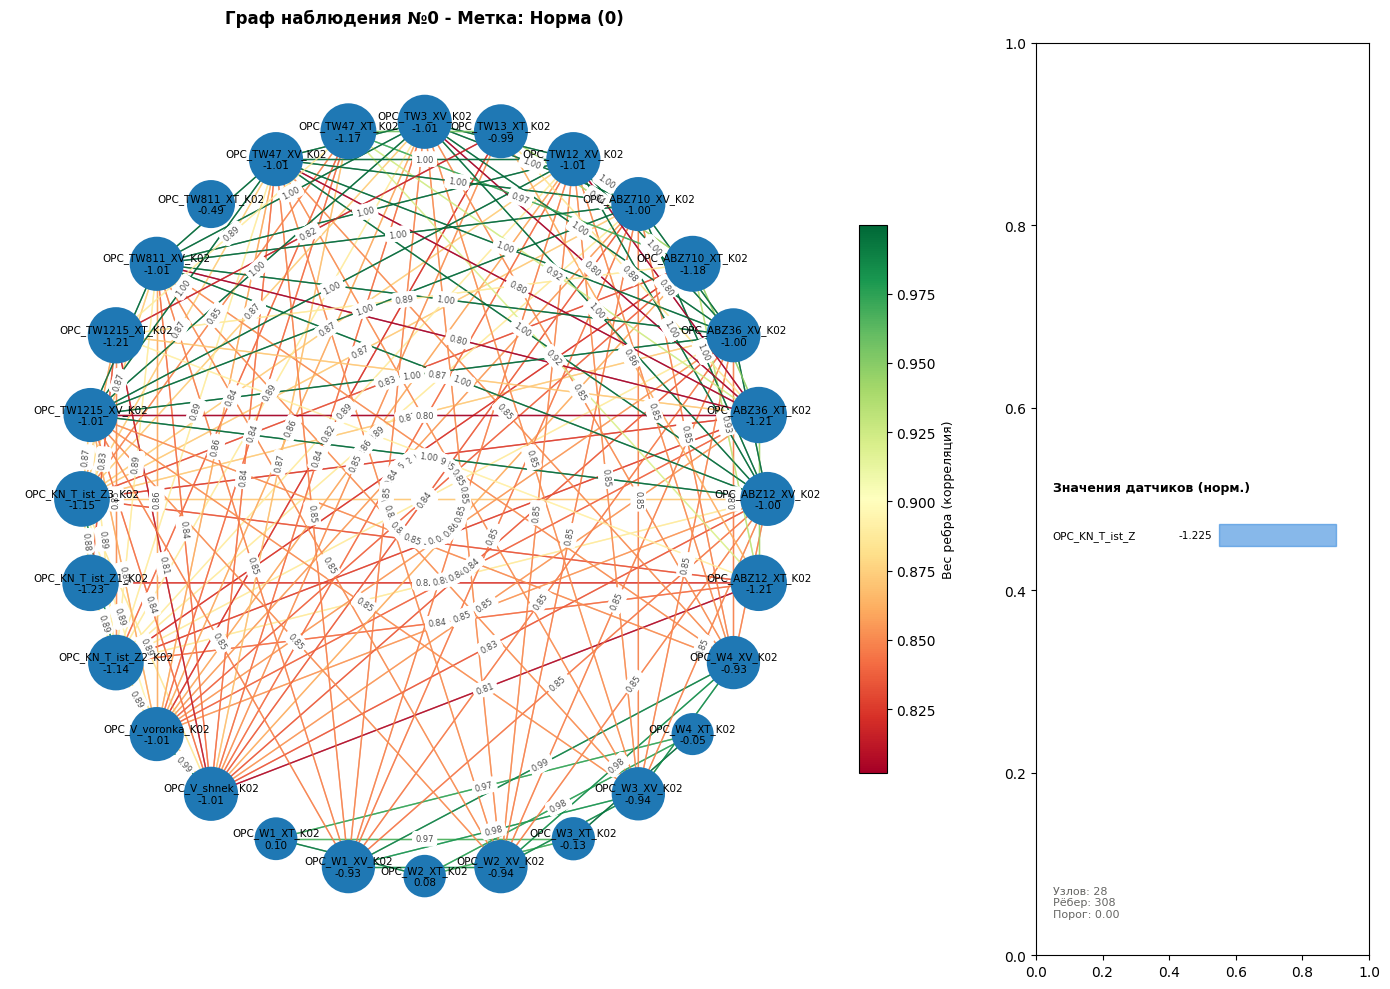

Сохранено: graph_sample.png


<Figure size 640x480 with 0 Axes>

Сохранено: graph_sample.png


<Figure size 640x480 with 0 Axes>

Сохранено: graph_sample.png


...

<Figure size 640x480 with 0 Axes>

Сохранено: graph_sample.png


<Figure size 640x480 with 0 Axes>

Сохранено: graph_sample.png


<Figure size 640x480 with 0 Axes>

In [82]:
visualize_graph(train_ds, edge_weight_threshold=0.0)